---
## Notebook para Tratamendo dos dados da variável resposta 
---

Criação de uma variável resposta 'cls_fin_ajustada'. Essa mudança ocorre por conta de valores nulos presentes nos dados, essencialmente presença por conta da perda de informação. Nesse caso, quando o valor é nulo, associaremos a classificação inicial 'tp_ev'.


---
### Imports e Leitura de dados

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
dados = pd.read_excel("/workspaces/CEA-1/sipnibancofinal.xls")
linhas, colunas = dados.shape
print("Dados:", linhas, "linhas e", colunas, "colunas")

Dados: 1083 linhas e 61 colunas


--- 
### Ajuste Inicial

In [3]:
dados['tp_ev'] = dados['tp_ev'].replace(
    'Não Grave (EANG) - Qualquer outro evento que não esteja incluído nos critéri',
    'EANG'
).replace('Erro de imunização com evento adverso', 'EI - evento adverso').replace('Erro de Imunização', 'EI').replace('Grave (EAG)', 'EAG')

dados['cls_fin'] = dados['cls_fin'].replace('Não Grave (EANG)','EANG').replace('Erro de Imunização - Com evento adverso', 'EI - evento adverso').replace('Erro de Imunização', 'EI').replace('Grave (EAG)', 'EAG')

print("Valores da variavel tp_ev:", dados['tp_ev'].unique())

print("Valores da variavel cls_fin:", dados['cls_fin'].unique())

Valores da variavel tp_ev: <StringArray>
['EANG', 'EI', 'EI - evento adverso', 'EAG']
Length: 4, dtype: str
Valores da variavel cls_fin: <StringArray>
[' ', 'EI', 'EANG', 'EAG', 'Inclassificável', 'EI - evento adverso']
Length: 6, dtype: str


---
### Valores nulos

In [9]:
dados['cls_fin'].unique()

<StringArray>
[' ', 'EI', 'EANG', 'EAG', 'Inclassificável', 'EI - evento adverso']
Length: 6, dtype: str

cls_fin
EI                     391
EANG                   374
                       277
EAG                     32
Inclassificável          8
EI - evento adverso      1
Name: count, dtype: int64


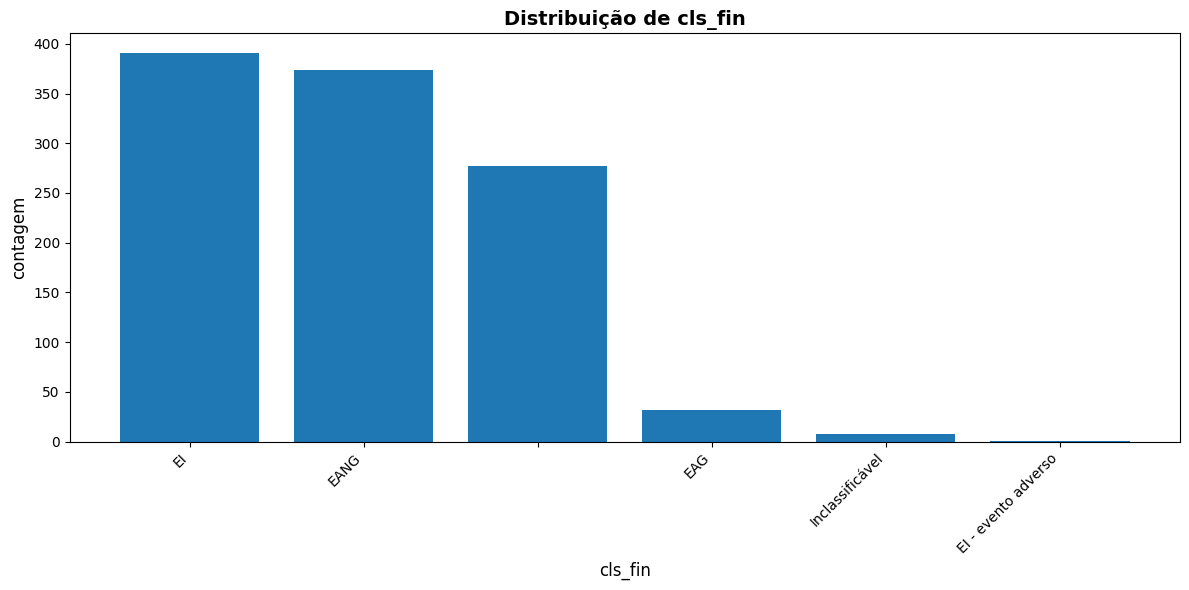

In [ ]:
uf_counts = dados['cls_fin'].value_counts().sort_values(ascending=False)

print(uf_counts)

plt.figure(figsize=(12, 6))
plt.bar(range(len(uf_counts)), uf_counts.values)
plt.xlabel('cls_fin', fontsize=12)
plt.ylabel('contagem', fontsize=12)
plt.title('Distribuição de cls_fin', fontsize=14, fontweight='bold')
plt.xticks(range(len(uf_counts)), uf_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()



tp_ev
EANG                   536
EI                     496
EAG                     46
EI - evento adverso      5
Name: count, dtype: int64


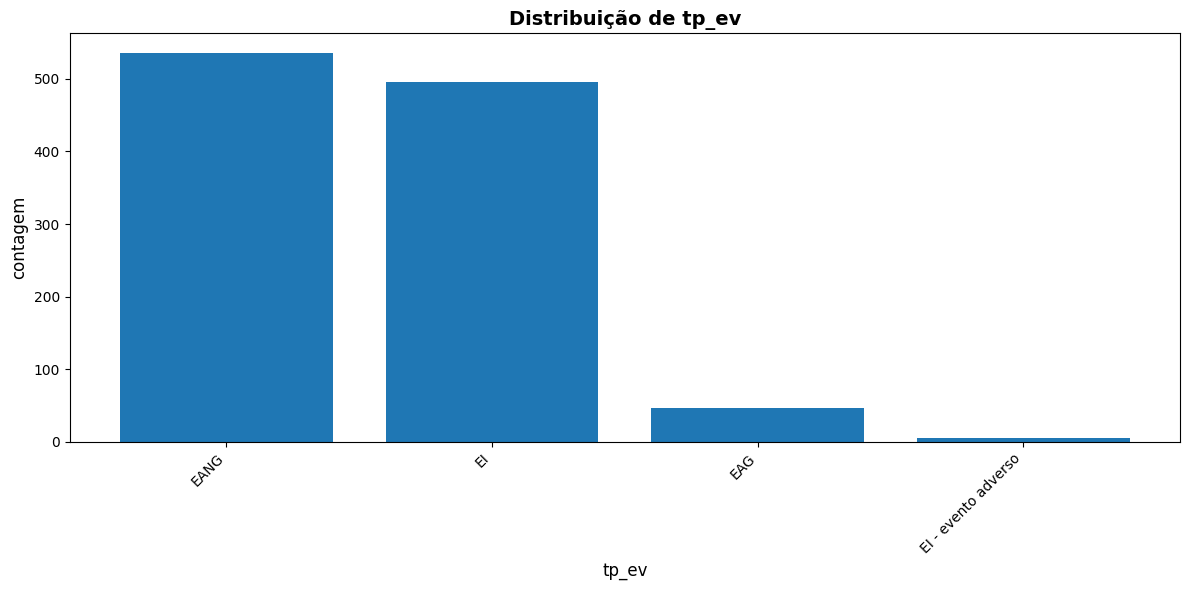

In [16]:
uf_counts = dados['tp_ev'].value_counts().sort_values(ascending=False)


print(uf_counts)
plt.figure(figsize=(12, 6))
plt.bar(range(len(uf_counts)), uf_counts.values)
plt.xlabel('tp_ev', fontsize=12)
plt.ylabel('contagem', fontsize=12)
plt.title('Distribuição de tp_ev', fontsize=14, fontweight='bold')
plt.xticks(range(len(uf_counts)), uf_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

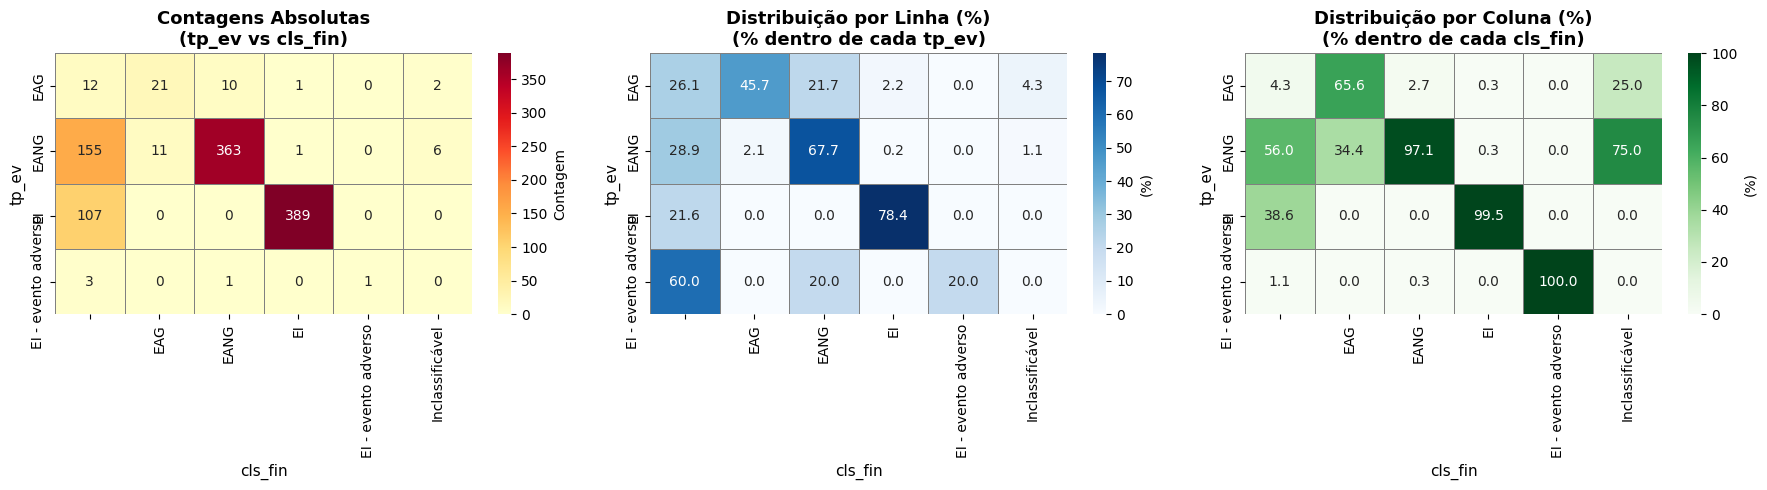

In [18]:
dados_resposta = dados[['tp_ev', 'cls_fin']]

contagem = pd.crosstab(dados_resposta['tp_ev'], dados_resposta['cls_fin'])
percentual_linhas = pd.crosstab(dados_resposta['tp_ev'], dados_resposta['cls_fin'], normalize='index') * 100
percentual_colunas = pd.crosstab(dados_resposta['tp_ev'], dados_resposta['cls_fin'], normalize='columns') * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(contagem, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Contagem'},
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Contagens Absolutas\n(tp_ev vs cls_fin)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('cls_fin', fontsize=11)
axes[0].set_ylabel('tp_ev', fontsize=11)

sns.heatmap(percentual_linhas, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '(%)'},
            ax=axes[1], linewidths=0.5, linecolor='gray')
axes[1].set_title('Distribuição por Linha (%)\n(% dentro de cada tp_ev)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('cls_fin', fontsize=11)
axes[1].set_ylabel('tp_ev', fontsize=11)

sns.heatmap(percentual_colunas, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': '(%)'},
            ax=axes[2], linewidths=0.5, linecolor='gray')
axes[2].set_title('Distribuição por Coluna (%)\n(% dentro de cada cls_fin)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('cls_fin', fontsize=11)
axes[2].set_ylabel('tp_ev', fontsize=11)

plt.tight_layout()
plt.show()

---
### Ajuste Final

In [15]:
dados['cls_fin_ajustada'] = dados.apply(
    lambda row: row['tp_ev'] if str(row['cls_fin']).strip() == '' else row['cls_fin'],
    axis=1
)

vazia = dados['cls_fin'].astype(str).str.strip() == ''
print("Linhas com cls_fin vazio: ", vazia.sum())

Linhas com cls_fin vazio:  277


cls_fin_ajustada
EANG                   529
EI                     498
EAG                     44
Inclassificável          8
EI - evento adverso      4
Name: count, dtype: int64


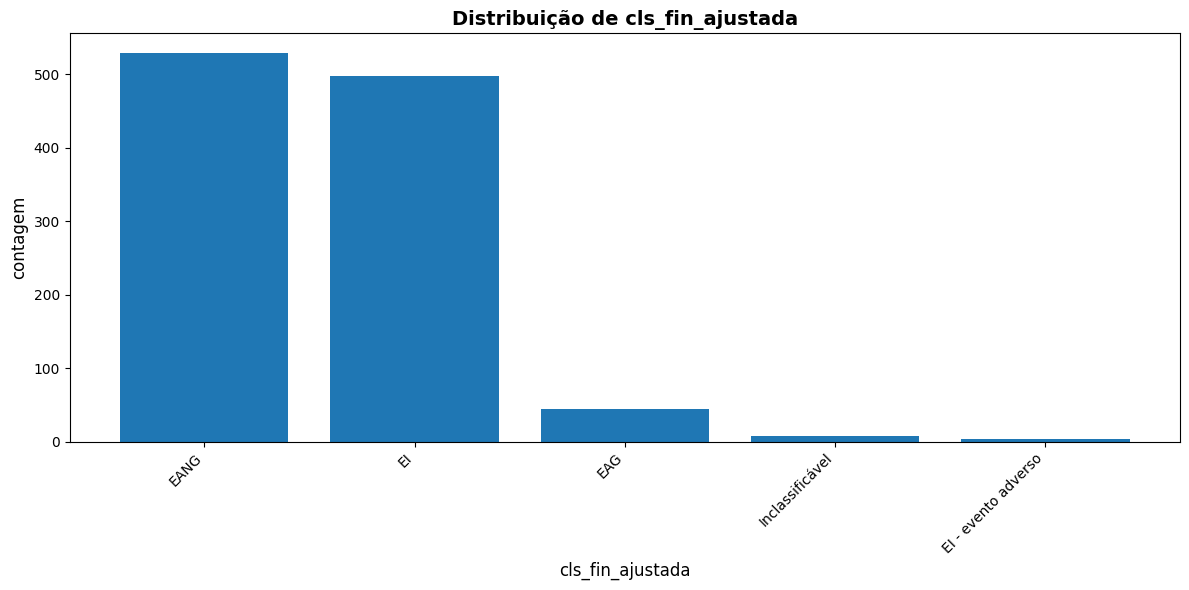

In [13]:
uf_counts = dados['cls_fin_ajustada'].value_counts().sort_values(ascending=False)

print(uf_counts)

plt.figure(figsize=(12, 6))
plt.bar(range(len(uf_counts)), uf_counts.values)
plt.xlabel('cls_fin_ajustada', fontsize=12)
plt.ylabel('contagem', fontsize=12)
plt.title('Distribuição de cls_fin_ajustada', fontsize=14, fontweight='bold')
plt.xticks(range(len(uf_counts)), uf_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

